# Tutorial 0: Building a 3D Radio Environment from Geographic Data

**Geo2SigMap** converts real-world geographic information into 3D scenes ready for RF signal simulation.
Starting from nothing more than a GPS location, it:

1. Queries building footprints from **OpenStreetMap** (OSM)
2. Estimates building heights from OSM tags or a statistical prior
3. Generates **3D triangle meshes** for buildings and ground
4. Writes a **Mitsuba / Sionna-compatible `scene.xml`** file referencing those meshes

This notebook walks through the full pipeline step-by-step — from choosing a GPS location to
inspecting the 3D outputs — so you have a solid understanding of the scene before handing it
off to a ray-tracing engine.

**What you'll learn**
- How to define a scene area from a single GPS point and dimensions in metres
- How the ITU-R P.2040-2 material library labels building surfaces
- How OSM footprints become extruded 3D meshes
- How to inspect `scene.xml`, PLY mesh files, and the 2D building height map

**Prerequisites:** The `scene_generation` package must be installed (see the repo README).
No GPU or Sionna installation is required for this tutorial.

## Pipeline overview

```
 GPS bounding box
       │
       ▼
 OpenStreetMap query  ──▶  building footprints (polygons)
       │                         │
       │                         ▼
       │                  height estimation
       │                  (OSM tags → statistical prior)
       │                         │
       ▼                         ▼
 ground mesh (PLY)      extruded building meshes (PLY)
       │                         │
       └──────────┬──────────────┘
                  ▼
             scene.xml
        (geometry + materials + metadata)
                  │
                  ▼
        2D Building Height Map (.npy)
```

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from pathlib import Path

from scene_generation.core import Scene
from scene_generation.utils import rect_from_point_and_size, get_utm_epsg_code_from_gps, gps_to_utm_xy
from scene_generation.itu_materials import ITU_MATERIALS

---
## Part 1 — Defining the Scene Boundary

The first step is choosing *where* to generate the scene.
Geo2SigMap needs a rectangular bounding box in GPS coordinates (WGS84 lon/lat).
The helper `rect_from_point_and_size` lets you specify:

- A **single GPS point** (the center or any corner of the rectangle)
- A **width × height in metres**

and returns the four corner coordinates back in GPS — no manual coordinate math required.

We'll use the center of **Dupont Circle** as our example location.

**Note: If you would like to modify this notebook and are utilizing our JupyterHub, please refrain from making maps larger than 500m x 500m. Thank You!**

In [2]:
# Scene center — DC
CENTER_LON = -77.043446
CENTER_LAT  =  38.909647

SCENE_WIDTH  = 500   # east–west extent, metres
SCENE_HEIGHT = 500   # north–south extent, metres

# rect_from_point_and_size returns a *closed* polygon:
#   [ bottom-left, top-left, top-right, bottom-right, bottom-left ]
# each point is a (longitude, latitude) tuple in WGS84.
scene_polygon = rect_from_point_and_size(
    CENTER_LON, CENTER_LAT, "center", SCENE_WIDTH, SCENE_HEIGHT
)

print(f"Scene center : ({CENTER_LON}°, {CENTER_LAT}°)")
print(f"Dimensions   : {SCENE_WIDTH} m (E–W)  ×  {SCENE_HEIGHT} m (N–S)")
print()
print("Bounding polygon corners (lon, lat):")
corner_labels = ["Bottom-left", "Top-left", "Top-right", "Bottom-right"]
for label, (lon, lat) in zip(corner_labels, scene_polygon):
    print(f"  {label:<14}: ({lon:.6f}°,  {lat:.6f}°)")

Scene center : (-77.043446°, 38.909647°)
Dimensions   : 500 m (E–W)  ×  500 m (N–S)

Bounding polygon corners (lon, lat):
  Bottom-left   : (-77.046263°,  38.907345°)
  Top-left      : (-77.046392°,  38.911848°)
  Top-right     : (-77.040629°,  38.911949°)
  Bottom-right  : (-77.040500°,  38.907446°)


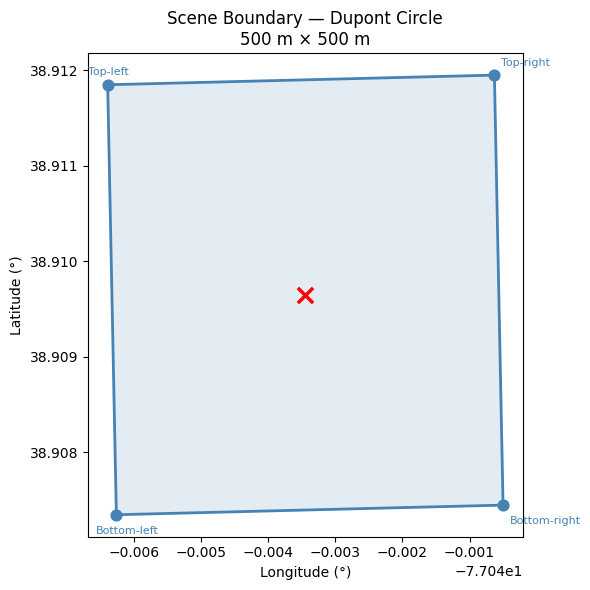

In [3]:
# Visualise the bounding box
lons = [p[0] for p in scene_polygon]
lats = [p[1] for p in scene_polygon]

fig, ax = plt.subplots(figsize=(6, 6))
ax.fill(lons, lats, alpha=0.15, color="steelblue")
ax.plot(lons, lats, color="steelblue", linewidth=2)
ax.scatter(lons[:-1], lats[:-1], color="steelblue", s=60, zorder=5)
ax.scatter([CENTER_LON], [CENTER_LAT], color="red", s=120, zorder=6,
           marker="x", linewidths=2.5, label="Scene center")

offsets = [(-0.0003, -0.0002), (-0.0003, 0.0001), (0.0001, 0.0001), (0.0001, -0.0002)]
for (lon, lat), label, (dx, dy) in zip(scene_polygon[:-1], corner_labels, offsets):
    ax.annotate(label, (lon + dx, lat + dy), fontsize=8, color="steelblue")

ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title(f"Scene Boundary — Dupont Circle\n{SCENE_WIDTH} m × {SCENE_HEIGHT} m")
#ax.legend()
plt.tight_layout()
plt.show()

### Coordinate systems inside Geo2SigMap

Working purely in GPS lon/lat is impractical for 3D geometry — one degree of longitude
changes its metric length with latitude, and distances aren't uniform. Geo2SigMap uses a
two-step conversion:

1. **WGS84 → UTM** — Projects the GPS bounding box into the appropriate
   [Universal Transverse Mercator](https://en.wikipedia.org/wiki/Universal_Transverse_Mercator_coordinate_system)
   zone (in metres). UTM gives equal-area, right-angle coordinates across the globe.
2. **UTM → local scene** — Subtracts the scene centroid so the origin is at **(0, 0, 0)**.
   All PLY mesh vertices are expressed in this local coordinate system.

The correct UTM zone is detected automatically from the GPS coordinates.

In [4]:
utm_crs = get_utm_epsg_code_from_gps(CENTER_LON, CENTER_LAT)
utm_x, utm_y, _ = gps_to_utm_xy(CENTER_LON, CENTER_LAT, utm_crs)

print("=== Coordinate System ===")
print(f"Input (WGS84)     lon = {CENTER_LON}°,  lat = {CENTER_LAT}°")
print(f"UTM projection    {utm_crs}")
print(f"UTM coordinates   x = {utm_x:,.2f} m  (easting)")
print(f"                  y = {utm_y:,.2f} m  (northing)")
print()
print("Inside the generated scene:")
print("  • Scene centroid becomes (0, 0) in local coordinates")
print("  • All building/ground vertices are relative to that local origin")
print("  • Heights (z-axis) are in metres above the local ground plane")

=== Coordinate System ===
Input (WGS84)     lon = -77.043446°,  lat = 38.909647°
UTM projection    EPSG:32618
UTM coordinates   x = 322,821.59 m  (easting)
                  y = 4,308,735.04 m  (northing)

Inside the generated scene:
  • Scene centroid becomes (0, 0) in local coordinates
  • All building/ground vertices are relative to that local origin
  • Heights (z-axis) are in metres above the local ground plane


---
## Part 2 — The Material Library

RF ray tracing depends critically on how electromagnetic waves **reflect** and **penetrate**
building surfaces. Geo2SigMap uses the
[ITU-R Recommendation P.2040-2](https://www.itu.int/dms_pubrec/itu-r/rec/p/R-REC-P.2040-3-202308-I!!PDF-E.pdf)
material library, which specifies measured dielectric properties (relative permittivity,
conductivity) for common building materials across a range of frequencies.

Every surface in the scene is assigned one of three **material roles**:

| Role | What it covers | Default |
|------|---------------|--------|
| **Ground** | Flat or terrain-shaped ground mesh | Wet Ground |
| **Rooftop** | Horizontal top of each building | Metal |
| **Wall** | Vertical sides of each building | Concrete |

Each role is assigned one ITU material, and that material's electrical properties
tell the ray tracer how much energy is reflected, transmitted, or absorbed at that surface.

In [5]:
# Build a summary table of all materials
records = []
for key, mat in ITU_MATERIALS.items():
    fl, fu = mat["lower_freq_limit"], mat["upper_freq_limit"]
    if isinstance(fl, list):
        freq = (f"{fl[0]/1e9:.3g}–{fu[0]/1e9:.0f} GHz"
                f"  +  {fl[1]/1e9:.0f}–{fu[1]/1e9:.0f} GHz")
    else:
        freq = f"{fl/1e9:.3g}–{fu/1e9:.0f} GHz"
    records.append({"Material key": key, "Name": mat["name"], "Valid freq range": freq})

df_mats = pd.DataFrame(records)
df_mats.index = range(1, len(df_mats) + 1)
df_mats

,Material key,Name,Valid freq range
1,mat-vacuum,Vacuum (≈Air),0.001–100 GHz
2,mat-itu_concrete,Concrete,1–100 GHz
3,mat-itu_brick,Brick,1–40 GHz
4,mat-itu_plasterboard,Plasterboard,1–100 GHz
5,mat-itu_wood,Wood,0.001–100 GHz
6,mat-itu_glass,Glass,0.1–100 GHz + 220–450 GHz
7,mat-itu_ceiling_board,Ceiling Board,1–100 GHz + 220–450 GHz
8,mat-itu_chipboard,Chipboard,1–100 GHz
9,mat-itu_plywood,Plywood,1–40 GHz
10,mat-itu_marble,Marble,1–60 GHz


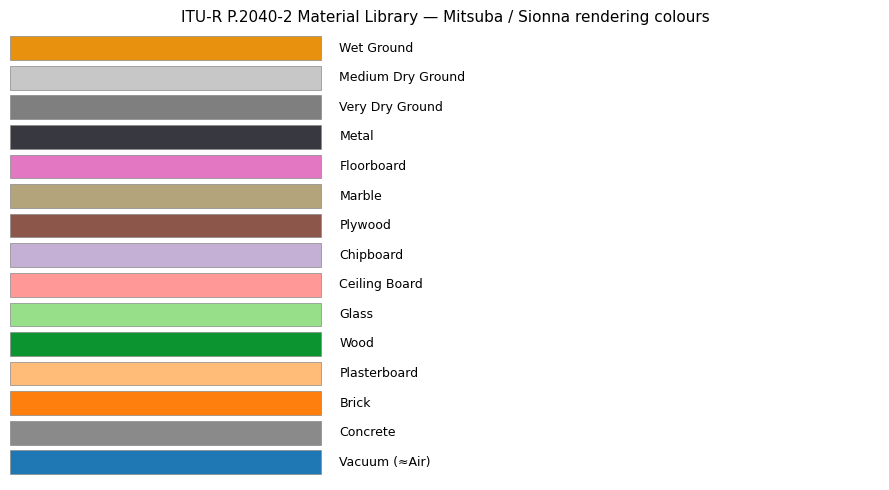

In [6]:
# Show Mitsuba / Sionna rendering colours for the core ITU P.2040-2 materials
# (exclude the extended-range P.527 variants)
itu_core = {k: v for k, v in ITU_MATERIALS.items() if "P.527" not in k}

names  = [m["name"]         for m in itu_core.values()]
colors = [m["mitsuba_color"] for m in itu_core.values()]

fig, ax = plt.subplots(figsize=(9, 5))
for i, (name, color) in enumerate(zip(names, colors)):
    ax.barh(i, 1, color=color, edgecolor="#888", linewidth=0.5)
    ax.text(1.06, i, name, va="center", fontsize=9)

ax.set_xlim(0, 2.8)
ax.set_ylim(-0.6, len(names) - 0.4)
ax.set_yticks([])
ax.set_xticks([])
ax.set_title("ITU-R P.2040-2 Material Library — Mitsuba / Sionna rendering colours",
             fontsize=11)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

---
## Part 3 — Generating the Scene

With the bounding box and material choices ready, a single call to `Scene()` runs the
full pipeline:

| Step | What happens |
|------|--------------|
| OSM query | Fetches building footprints from the Overpass API |
| Height estimation | Assigns a height to each building (see Part 6) |
| Ground mesh | Triangulates the bounding polygon as a flat ground plane |
| Building meshes | Extrudes each footprint by its height; separates rooftop from walls |
| `scene.xml` | Writes a Mitsuba/Sionna scene file linking meshes to materials |
| Height map | Renders a 2D grayscale image encoding per-pixel building heights |

Key parameters:

| Parameter | Description |
|-----------|-------------|
| `points` | Closed polygon of (lon, lat) corners |
| `data_dir` | Output directory for all generated files |
| `hag_tiff_path` | Path to a LiDAR Height-Above-Ground raster; `None` = no LiDAR |
| `*_material_type` | ITU material key for ground, rooftops, and walls |
| `generate_building_map` | Whether to produce the 2D height map |
| `lidar_terrain` / `dem_terrain` | Whether to use elevation data for the terrain mesh |

> **Note:** The OSM query requires an internet connection.
> A 500 m × 500 m scene typically takes **30–90 seconds** depending on building density
> and network latency.

In [7]:
DATA_DIR = "./scenes/dupont"
os.makedirs(DATA_DIR, exist_ok=True)
print(f"Output directory: {os.path.abspath(DATA_DIR)}")

Output directory: /Users/rtang/athena-ai/geo2sigmap-fork/research/examples/scenes/dupont


In [8]:
scene = Scene()

# Generate the scene using our private OSM server (http://192.168.1.101/api/interpreter)
# If our server is down, please use the public server by changing osm_server_addr to:
# https://overpass-api.de/api/interpreter

building_height_map = scene(
    points=scene_polygon,
    data_dir=DATA_DIR,
    osm_server_addr="https://overpass-api.de/api/interpreter",
    hag_tiff_path=None,                       # No LiDAR calibration in this tutorial
    ground_material_type="mat-itu_wet_ground",
    rooftop_material_type="mat-itu_metal",
    wall_material_type="mat-itu_concrete",
    generate_building_map=True,
    # Adding lidar and dem terrain flags
    # lidar_calibration=True,
    # lidar_terrain=True,
    # dem_terrain=True,
)

print("\nScene generation complete!")

Parsing buildings: 100%|██████████| 357/357 [00:00<00:00, 873.76it/s]


Scene generation complete!


---
## Part 4 — Exploring the Outputs

After generation, the output directory contains:

| File / folder | Description |
|---------------|-------------|
| `scene.xml` | Mitsuba/Sionna scene — materials, geometry references, metadata |
| `2D_Building_Height_Map.npy` | 2D NumPy array; pixel value = building height in metres |
| `mesh/ground.ply` | Triangle mesh for the flat ground plane |
| `mesh/building_N_rooftop.ply` | Top-face mesh for building N |
| `mesh/building_N_wall.ply` | Side-face mesh for building N |

Let's inspect each of these.

In [9]:
# Print directory tree with file sizes
mesh_dir = Path(DATA_DIR) / "mesh"
mesh_files = sorted(mesh_dir.iterdir())

rooftop_files = [f for f in mesh_files if "rooftop" in f.name]
wall_files    = [f for f in mesh_files if "wall"    in f.name]
ground_files  = [f for f in mesh_files if "ground"  in f.name]
n_buildings   = len(rooftop_files)

print(f"{DATA_DIR}/")
for fpath in sorted(Path(DATA_DIR).iterdir()):
    if fpath.is_file():
        kb = fpath.stat().st_size / 1024
        print(f"  {fpath.name:<40} ({kb:>6.1f} KB)")

print(f"  mesh/")
for f in ground_files:
    kb = f.stat().st_size / 1024
    print(f"    {f.name:<38} ({kb:>6.1f} KB)")
if n_buildings > 0:
    last = n_buildings - 1
    print(f"    building_0_rooftop.ply … building_{last}_rooftop.ply  ({n_buildings} files)")
    print(f"    building_0_wall.ply     … building_{last}_wall.ply     ({n_buildings} files)")

total_mb = sum(f.stat().st_size for f in mesh_files) / 1024**2
print()
print(f"Buildings in scene : {n_buildings}")
print(f"Total mesh size    : {total_mb:.2f} MB")

./scenes/dupont/
  2D_Building_Height_Map.npy               ( 245.2 KB)
  scene.xml                                ( 165.9 KB)
  mesh/
    ground.ply                             (   0.3 KB)
    building_0_rooftop.ply … building_350_rooftop.ply  (351 files)
    building_0_wall.ply     … building_350_wall.ply     (351 files)

Buildings in scene : 351
Total mesh size    : 0.64 MB


### Scene metadata in `scene.xml`

Geo2SigMap embeds scene metadata as `<default>` elements at the top of the XML.
This makes the scene self-describing: any tool that reads `scene.xml` can recover
the bounding box, material choices, UTM zone, and version without needing a sidecar file.

In [10]:
# Parse scene.xml and display metadata
tree = ET.parse(os.path.join(DATA_DIR, "scene.xml"))
root = tree.getroot()

meta = {e.get("name"): e.get("value") for e in root.findall("default")}

labels = {
    "scenegen_version":          "Geo2SigMap version",
    "scenegen_create_time":      "Created at",
    "scenegen_UTM_zone":         "UTM projection",
    "scenegen_center_lon":       "Center longitude",
    "scenegen_center_lat":       "Center latitude",
    "scenegen_bbox_width":       "Scene width (m)",
    "scenegen_bbox_length":      "Scene height (m)",
    "scenegen_ground_material":  "Ground material",
    "scenegen_rooftop_material": "Rooftop material",
    "scenegen_wall_material":    "Wall material",
}

print("=== Scene Metadata (from scene.xml) ===\n")
for key, label in labels.items():
    if key in meta:
        print(f"  {label:<26} {meta[key]}")

# Count XML shape elements
shapes          = root.findall("shape")
ground_shapes   = [s for s in shapes if s.get("id") == "mesh-ground"]
building_shapes = [s for s in shapes if "building" in s.get("id", "")]
print(f"\n  Ground mesh shapes    : {len(ground_shapes)}")
print(f"  Building mesh shapes  : {len(building_shapes)}"
      f"  ({len(building_shapes)//2} buildings × 2 surfaces)")

=== Scene Metadata (from scene.xml) ===

  Geo2SigMap version         1.0.0
  Created at                 2026-06-08 16:58:45.158208
  UTM projection             EPSG:32618
  Center longitude           -77.043446
  Center latitude            38.909647
  Scene width (m)            501
  Scene height (m)           501
  Ground material            mat-itu_wet_ground
  Rooftop material           mat-itu_metal
  Wall material              mat-itu_concrete

  Ground mesh shapes    : 1
  Building mesh shapes  : 702  (351 buildings × 2 surfaces)


---
## Part 5 — The 2D Building Height Map

When `generate_building_map=True`, Geo2SigMap produces a 2D array saved as
`2D_Building_Height_Map.npy`.
Each **pixel corresponds to one square metre** of the scene, and its value is the
building height in metres (0 = open ground).

This map is useful for:
- **Visual sanity-checking** — Does the scene look right? Are buildings where expected?
- **U-Net signal prediction** — The map is an input feature for the ML coverage model
  (covered in a later tutorial)
- **Scene statistics** — Quickly compute building density, height distribution, etc.

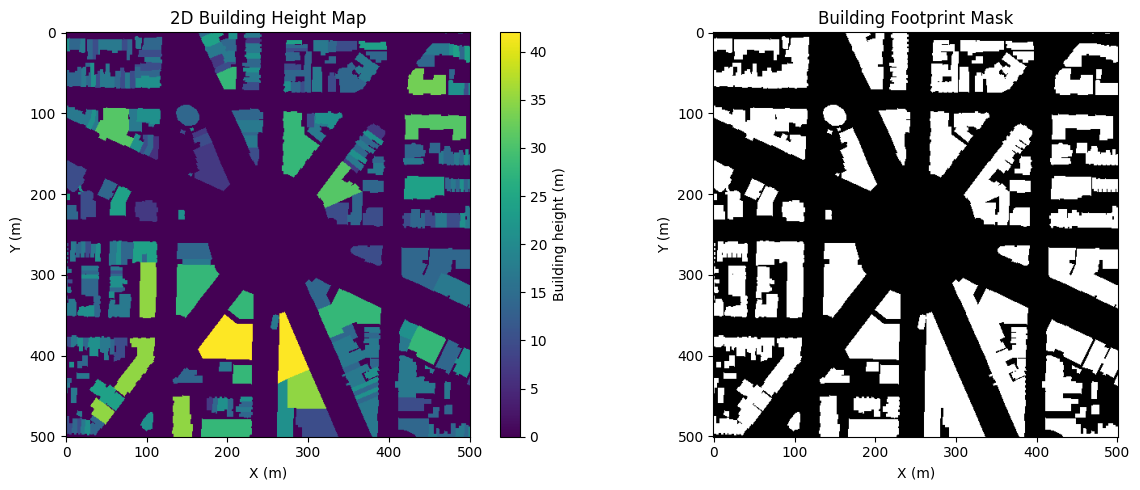

Height map shape   : 501 × 501 pixels (1 px = 1 m²)
Height range       : 6.0 – 42.0 m
Building coverage  : 37.2% of scene area


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: height values
im = axes[0].imshow(building_height_map, cmap="viridis", origin="upper")
plt.colorbar(im, ax=axes[0], label="Building height (m)")
axes[0].set_title("2D Building Height Map")
axes[0].set_xlabel("X (m)")
axes[0].set_ylabel("Y (m)")

# Right: binary footprint mask (building vs. open ground)
mask = building_height_map > 0
axes[1].imshow(mask, cmap="gray", origin="upper")
axes[1].set_title("Building Footprint Mask")
axes[1].set_xlabel("X (m)")
axes[1].set_ylabel("Y (m)")

plt.tight_layout()
plt.show()

coverage = 100 * mask.sum() / mask.size
h_vals   = building_height_map[mask]
print(f"Height map shape   : {building_height_map.shape[1]} × {building_height_map.shape[0]} pixels (1 px = 1 m²)")
print(f"Height range       : {h_vals.min():.1f} – {h_vals.max():.1f} m")
print(f"Building coverage  : {coverage:.1f}% of scene area")

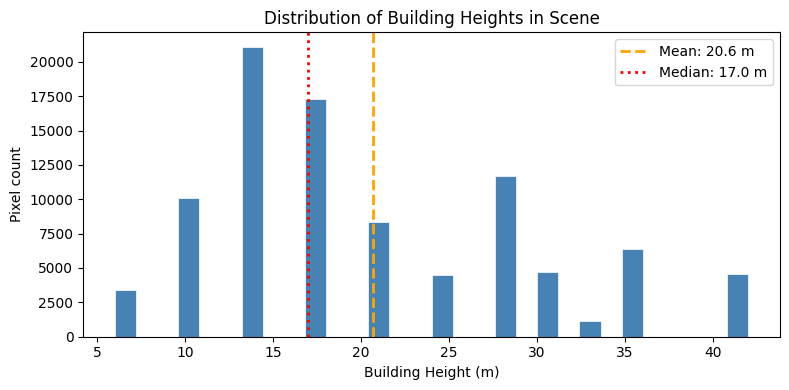

In [12]:
heights = building_height_map[building_height_map > 0].ravel()
mean_h   = heights.mean()
median_h = np.median(heights)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(heights, bins=30, color="steelblue", edgecolor="white", linewidth=0.5)
ax.axvline(mean_h,   color="orange", linestyle="--", linewidth=2,
           label=f"Mean: {mean_h:.1f} m")
ax.axvline(median_h, color="red",    linestyle=":",  linewidth=2,
           label=f"Median: {median_h:.1f} m")
ax.set_xlabel("Building Height (m)")
ax.set_ylabel("Pixel count")
ax.set_title("Distribution of Building Heights in Scene")
ax.legend()
plt.tight_layout()
plt.show()

---
## Part 6 — How Building Heights Are Estimated

OpenStreetMap contributors tag buildings with varying levels of detail.
Geo2SigMap handles this with a **four-tier priority chain** inside
`scene_generation.utils.random_building_height`:

| Priority | OSM tag | How it's used |
|----------|---------|---------------|
| 1 (highest) | `building:height` | Used directly in metres |
| 2 | `height` | Used directly in metres |
| 3 | `building:levels` | Multiplied by **3.5 m/floor** |
| 4 (fallback) | *(none)* | Gaussian: N(μ=5, σ=1) floors × 3.5 m, clamped to [1, 15] floors |

The Gaussian fallback (mean 5 floors ≈ 17.5 m) reflects typical urban building stock
and ensures every footprint gets a plausible height even when OSM data is sparse.
This is also why the height distribution above looks roughly Gaussian peaked around
one floor height — most buildings in OSM don't have explicit height tags.

In [13]:
# Illustrate the height estimation logic with concrete examples 
np.random.seed(42)

def estimate_height_demo(tags: dict):
    """Simplified mirror of scene_generation.utils.random_building_height."""
    def is_float(v):
        try: float(v); return True
        except (ValueError, TypeError): return False

    if "building:height" in tags and is_float(tags["building:height"]):
        return float(tags["building:height"]), "building:height tag"
    if "height" in tags and is_float(tags["height"]):
        return float(tags["height"]), "height tag"
    if "building:levels" in tags and is_float(tags["building:levels"]):
        return float(tags["building:levels"]) * 3.5, "building:levels × 3.5 m/floor"
    floors = max(1, min(15, int(np.random.normal(loc=5, scale=1))))
    return floors * 3.5, f"Gaussian fallback ({floors} floors × 3.5 m)"

examples = [
    {"building": "office",      "building:height": "42.0"},
    {"building": "commercial",  "height": "12"},
    {"building": "residential", "building:levels": "3"},
    {"building": "yes"},
    {"building": "yes"},   # second random sample to show variability
]

print(f"{'OSM tags':<52}  {'Height':>8}  Method")
print("-" * 95)
for tags in examples:
    h, method = estimate_height_demo(tags)
    print(f"  {str(tags):<50}  {h:>6.1f} m  {method}")

OSM tags                                                Height  Method
-----------------------------------------------------------------------------------------------
  {'building': 'office', 'building:height': '42.0'}     42.0 m  building:height tag
  {'building': 'commercial', 'height': '12'}            12.0 m  height tag
  {'building': 'residential', 'building:levels': '3'}    10.5 m  building:levels × 3.5 m/floor
  {'building': 'yes'}                                   17.5 m  Gaussian fallback (5 floors × 3.5 m)
  {'building': 'yes'}                                   14.0 m  Gaussian fallback (4 floors × 3.5 m)


---
## Part 7 — Inside `scene.xml`

`scene.xml` is a [Mitsuba 2](https://mitsuba-renderer.org/) / Sionna scene file with
three main sections:

```
<scene>
  <!-- 1. Metadata ─────────────────────────────────────────── -->
  <default name="scenegen_version"  value="..."/>
  <default name="scenegen_center_lat" value="..."/>
  ...  (bounding box, materials, UTM zone, etc.)

  <!-- 2. Material definitions ──────────────────────────────── -->
  <bsdf type="twosided" id="mat-itu_concrete">
    <bsdf type="diffuse">
      <rgb name="reflectance" value="0.539 0.539 0.539"/>
    </bsdf>
  </bsdf>
  ...  (one entry per ITU material)

  <!-- 3. Geometry (one <shape> per PLY file) ───────────────── -->
  <shape type="ply" id="mesh-ground">
    <string name="filename" value="mesh/ground.ply"/>
    <ref id="mat-itu_wet_ground" name="bsdf"/>
  </shape>
  <shape type="ply" id="mesh-building_0_rooftop">
    <string name="filename" value="mesh/building_0_rooftop.ply"/>
    <ref id="mat-itu_metal" name="bsdf"/>
  </shape>
  ...
</scene>
```

When loaded into Sionna's `load_scene()`, the `<ref>` elements map each mesh surface
to its material's electrical properties, which the ray tracer uses to compute
reflection, diffraction, and transmission at each bounce.

In [14]:
# Show the opening of scene.xml to make the structure concrete
with open(os.path.join(DATA_DIR, "scene.xml")) as f:
    lines = f.readlines()

print("scene.xml (first 55 lines):\n")
print("".join(lines[:55]))

scene.xml (first 55 lines):

<?xml version="1.0" ?>
<scene version="2.1.0">
    <default name="spp" value="4096"/>
    <default name="resx" value="1024"/>
    <default name="resy" value="1024"/>
    <default name="scenegen_version" value="1.0.0"/>
    <default name="scenegen_create_time" value="2026-06-08 16:58:45.158208"/>
    <default name="scenegen_min_lat" value="38.90734507416146"/>
    <default name="scenegen_max_lat" value="38.91184794227801"/>
    <default name="scenegen_min_lon" value="-77.04626294005713"/>
    <default name="scenegen_max_lon" value="-77.04062887811922"/>
    <default name="scenegen_ground_material" value="mat-itu_wet_ground"/>
    <default name="scenegen_rooftop_material" value="mat-itu_metal"/>
    <default name="scenegen_wall_material" value="mat-itu_concrete"/>
    <default name="scenegen_UTM_zone" value="EPSG:32618"/>
    <integrator type="path">
        <integer name="max_depth" value="12"/>
    </integrator>
    <bsdf type="twosided" id="mat-itu_concret

## Part 8 — Visualizing `scene.xml`

We use the built-in Sionna helper function to see our completed scene.

In [15]:
from sionna.rt import scene, preview

dc_scene = scene.load_scene("./scenes/dupont/scene.xml")
dc_scene.preview()

2026-06-08 16:59:53 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).


---
## Summary

In this tutorial we:

1. **Defined a scene** from a single GPS point and metre dimensions using `rect_from_point_and_size`
2. **Understood the coordinate pipeline**: GPS → UTM → local (0, 0, 0) origin
3. **Explored the ITU-R P.2040-2 material library** and how it maps onto building surfaces
4. **Generated a scene** by calling `Scene()` — OSM query, height estimation, mesh extrusion, XML output
5. **Inspected the outputs**: directory structure, XML metadata, 2D building height map
6. **Traced the height estimation logic**: four-tier fallback from OSM tags to Gaussian prior
7. **Read the scene.xml structure**: metadata, material BSDF definitions, and shape references
8. **Visualized our generated scene using the helper function available in Sionna RT**

---
## Next Steps: Bbox Finder Walkthrough

Link to the website: https://bboxfinder.com/#0.000000,0.000000,0.000000,0.000000

1. Pan and zoom to your desired location.
2. Click on the "box" icon.
3. Drag the box over the target area.
4. Store/copy the GPS coordinates into your scene generation call (CLI or API)